<a href="https://colab.research.google.com/github/oalbusaidi/C-lang-CS50/blob/master/twitter_anlyse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
import warnings 


%matplotlib inline
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv("Twitter Sentiments.csv")
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [5]:
def remove(input_text,pattern):
  r= re.findall(pattern,input_text)
  for word in r:
    input_text = re.sub(word,'',input_text)
  return input_text

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [6]:
#remove twitter user (@user)
df['cleaned_tweets']=np.vectorize(remove)(df['tweet'],"@[\w]*")

In [7]:
df.head()

,id,label,tweet,cleaned_tweets
0,1,0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so sel...
1,2,0,@user @user thanks for #lyft credit i can't us...,thanks for #lyft credit i can't use cause th...
2,3,0,bihday your majesty,bihday your majesty
3,4,0,#model i love u take with u all the time in ...,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation,factsguide: society now #motivation


In [9]:
#remove panctuation and others
df['cleaned_tweets']=df['cleaned_tweets'].str.replace("[^a-zA-z#]"," ")



In [10]:
df['cleaned_tweets']=df['cleaned_tweets'].apply(lambda x: " ".join([w for w in x.split() if len(w)>3]))
df.head()

,id,label,tweet,cleaned_tweets
0,1,0,@user when a father is dysfunctional and is s...,when father dysfunctional selfish drags kids i...
1,2,0,@user @user thanks for #lyft credit i can't us...,thanks #lyft credit cause they offer wheelchai...
2,3,0,bihday your majesty,bihday your majesty
3,4,0,#model i love u take with u all the time in ...,#model love take with time
4,5,0,factsguide: society now #motivation,factsguide society #motivation


In [11]:
#seprate all words as tokense
toknized_tweet= df['cleaned_tweets'].apply(lambda x: x.split())
toknized_tweet.head()

0    [when, father, dysfunctional, selfish, drags, ...
1    [thanks, #lyft, credit, cause, they, offer, wh...
2                              [bihday, your, majesty]
3                     [#model, love, take, with, time]
4                   [factsguide, society, #motivation]
Name: cleaned_tweets, dtype: object

In [12]:
from nltk.stem.snowball import PorterStemmer
#stem the words
stemmer = PorterStemmer()

toknized_tweet = toknized_tweet.apply(lambda sentence: [stemmer.stem(word) for word in sentence])
toknized_tweet.head()

0    [when, father, dysfunct, selfish, drag, kid, i...
1    [thank, #lyft, credit, caus, they, offer, whee...
2                              [bihday, your, majesti]
3                     [#model, love, take, with, time]
4                         [factsguid, societi, #motiv]
Name: cleaned_tweets, dtype: object

In [13]:
from IPython.core.inputtransformer2 import tokenize
#combine words into in sntence
for i in range(len(toknized_tweet)):
  toknized_tweet[i]=" ".join(toknized_tweet[i])

df['cleaned_tweets'] = toknized_tweet
df.head()

,id,label,tweet,cleaned_tweets
0,1,0,@user when a father is dysfunctional and is s...,when father dysfunct selfish drag kid into dys...
1,2,0,@user @user thanks for #lyft credit i can't us...,thank #lyft credit caus they offer wheelchair ...
2,3,0,bihday your majesty,bihday your majesti
3,4,0,#model i love u take with u all the time in ...,#model love take with time
4,5,0,factsguide: society now #motivation,factsguid societi #motiv


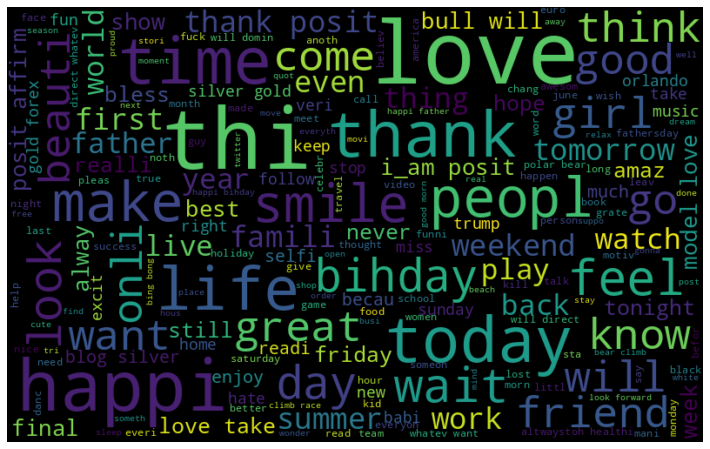

In [14]:
import wordcloud
#all frequent words
all_words = " ".join([sentence for sentence in df['cleaned_tweets']])

from wordcloud import WordCloud

wordcloud = WordCloud(width = 800,height = 500,random_state= 42,max_font_size=100).generate(all_words)

#plot all words
plt.figure(figsize=(15,8))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()

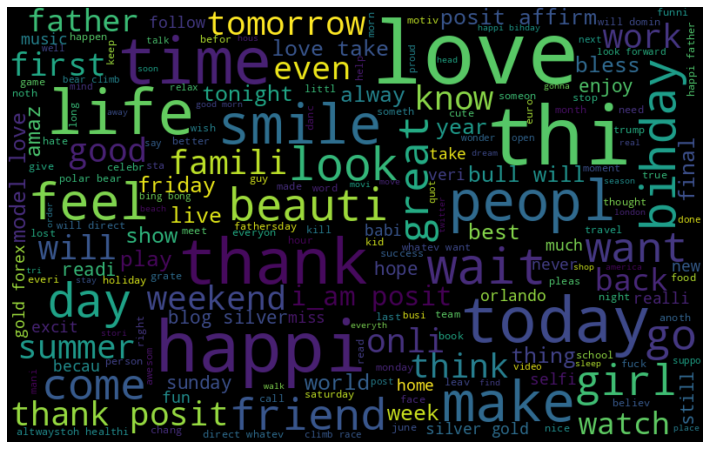

In [15]:
#frequent words for positve
#all frequent words
all_words = " ".join([sentence for sentence in df['cleaned_tweets'][df['label']==0]])


wordcloud = WordCloud(width = 800,height = 500,random_state= 42,max_font_size=100).generate(all_words)

#plot all words
plt.figure(figsize=(15,8))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()


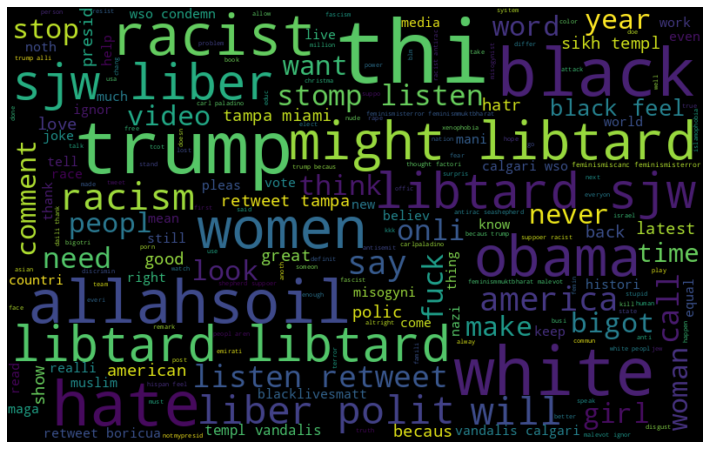

In [53]:
#frequent words for negative
#all frequent words
all_words = " ".join([sentence for sentence in df['cleaned_tweets'][df['label']==1]])


wordcloud = WordCloud(width = 800,height = 500,random_state= 42,max_font_size=100).generate(all_words)

#plot all words
plt.figure(figsize=(15,8))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()


In [54]:
#extract hashtage

def extract_hashtage(tweets):
    hashtages= []

    for tweet in tweets:
      ht = re.findall(r"#(\w+)",tweet)
      hashtages.append(ht)
    return hashtages    

In [56]:
#extractt hashtags from positive

ht_positive = extract_hashtage(df['cleaned_tweets'][df['label']==0])

#extractt hashtags from negative

ht_negative = extract_hashtage(df['cleaned_tweets'][df['label']==1])


In [57]:
ht_positive[0:5]


[['run'], ['lyft', 'disapoint', 'getthank'], [], ['model'], ['motiv']]

In [58]:
ht_positive = sum(ht_positive,[])
ht_negative = sum(ht_negative,[])

In [59]:
ht_positive[0:5]

['run', 'lyft', 'disapoint', 'getthank', 'model']

In [60]:
freq = nltk.FreqDist(ht_positive)
d = pd.DataFrame({'Hashtag': list(freq.keys()),
                    'Count': list(freq.values())})
d.head()

,Hashtag,Count
0,run,72
1,lyft,2
2,disapoint,1
3,getthank,2
4,model,375


<function matplotlib.pyplot.show(close=None, block=None)>

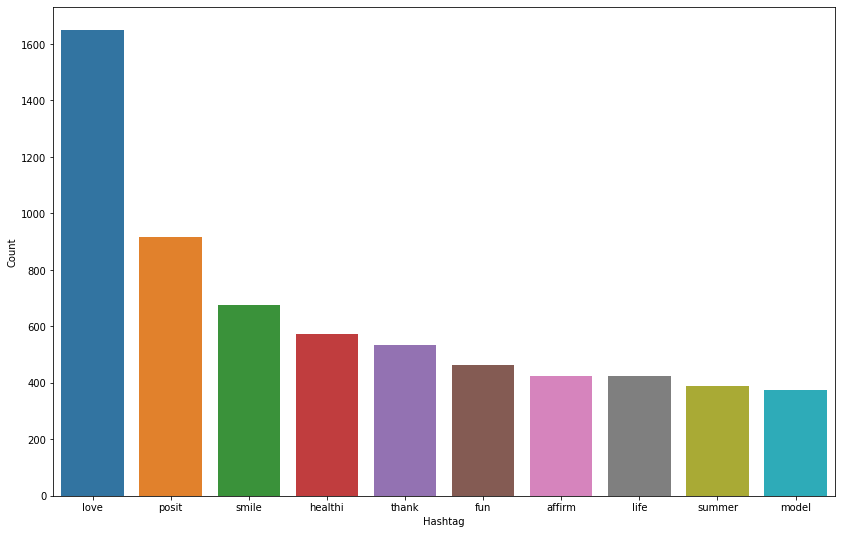

In [61]:
#select top 10 hashtages
d= d.nlargest(columns='Count', n=10)
plt.figure(figsize=(14,9))
sns.barplot(data=d,x='Hashtag',y='Count')
plt.show

In [62]:
freqs = nltk.FreqDist(ht_negative)
da = pd.DataFrame({'Hashtag': list(freqs.keys()),
                    'Count': list(freqs.values())})
da.head()


,Hashtag,Count
0,cnn,10
1,michigan,2
2,tcot,14
3,australia,6
4,opkillingbay,5


<function matplotlib.pyplot.show(close=None, block=None)>

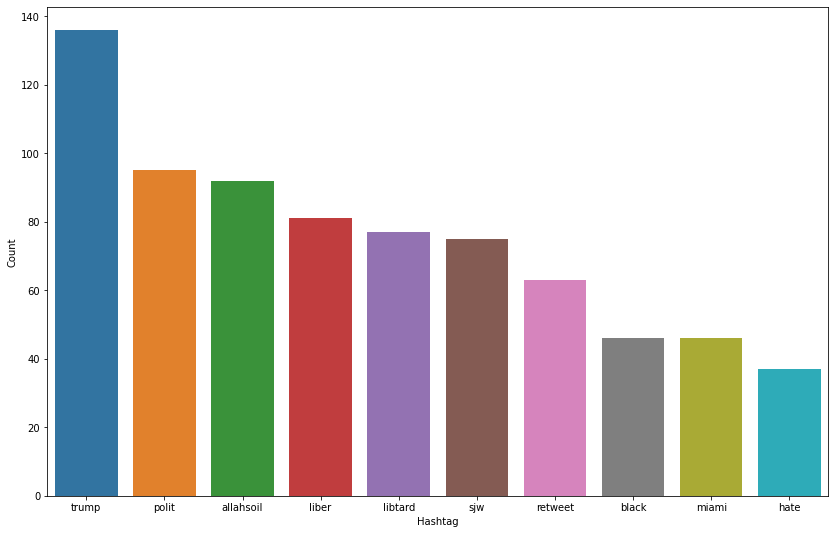

In [63]:
#select top 10 hashtages
d= da.nlargest(columns='Count', n=10)
plt.figure(figsize=(14,9))
sns.barplot(data=d,x='Hashtag',y='Count')
plt.show

In [65]:
#feature extraxtion
from sklearn.feature_extraction.text import CountVectorizer
bowv = CountVectorizer(max_df=0.9,min_df=2,max_features=1000,stop_words='english')
bow= bowv.fit_transform(df['cleaned_tweets'])

In [ ]:
#bow[0].toarray()

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(bow, df['label'], test_size=0.25, random_state=42)


In [74]:
#training
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score,accuracy_score

In [75]:
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [77]:
#testing
predi = model.predict(X_test)
f1_score(y_test,predi)


0.49763033175355453

In [78]:
print('accuracy score is:',accuracy_score(y_test,predi))

accuracy score is: 0.9469403078463271


In [84]:
pred_prob= model.predict_proba(X_test)
predi = pred_prob[:,1]>=0.3
predi=predi.astype(np.int)
f1_score(y_test,predi)

0.5545722713864307

In [85]:
pred_prob[0][1]>=0.3

False